# Deep Learning Cataract Detection
## Phase 1: Data Preparation & Stratification
I load `full_df.csv`, keep the `filename` and `C` (Cataract indicator) columns.
To ensure I properly clean the data, I verify that each `filename` actually exists in the `preprocessed_images/` directory before keeping the row.
Then I split the dataset into Train (70%), Valid (15%), and Test (15%) using stratified splitting.

In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)


!ls "/content/drive/MyDrive/Colab_Contents/cataract"

Mounted at /content/drive
cataract  full_df.csv  preprocessed_images


In [2]:
!ln -s "/content/drive/MyDrive/Colab_Contents/cataract" "/content/cataract"

In [18]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch.nn as nn
import torchvision.models as models
from torchvision.models import ResNet50_Weights
import torch.optim as optim
import copy
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


In [4]:
def load_and_clean_data(csv_path: str, image_dir: str) -> pd.DataFrame:
    """
    Loads the label dataframe and filters out filenames that don't physically exist in the image directory.
    """
    print(f"Loading dataframe from {csv_path}...")
    full_df = pd.read_csv(csv_path)

    data = full_df[['filename', 'C']].copy()
    initial_count = len(data)

    print("Verifying image existence...")
    data['file_exists'] = data['filename'].apply(lambda name: os.path.exists(os.path.join(image_dir, str(name))))

    clean_data = data[data['file_exists'] == True].copy()
    final_count = len(clean_data)

    print(f"Initial rows: {initial_count}")
    print(f"Missing images removed: {initial_count - final_count}")
    print(f"Valid rows remaining: {final_count}")
    print(f"Total positive Cataract cases (C=1) remaining: {clean_data['C'].sum()}")

    return clean_data.drop(columns=['file_exists'])



In [5]:
def split_dataset_stratified(clean_metadata: pd.DataFrame):
    """
    Splits the valid dataset into Train (70%), Validation (15%), and Test (15%).
    Uses stratification on the 'C' column to keep the extreme minority class (Cataract)
    proportionally balanced across all splits.
    """
    print("\nSplitting dataset into [Train 70% | Val 15% | Test 15%]...")
    train_df, temp_df = train_test_split(
        clean_metadata,
        test_size=0.30,
        stratify=clean_metadata['C'],
        random_state=42
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        stratify=temp_df['C'],
        random_state=42
    )

    print(f"Train Set: {len(train_df)} samples, Cataract Cases: {train_df['C'].sum()} ({train_df['C'].mean()*100:.2f}%)")
    print(f"Validation Set: {len(val_df)} samples, Cataract Cases: {val_df['C'].sum()} ({val_df['C'].mean()*100:.2f}%)")
    print(f"Test Set: {len(test_df)} samples, Cataract Cases: {test_df['C'].sum()} ({test_df['C'].mean()*100:.2f}%)")

    return train_df, val_df, test_df


In [6]:
# ========================================
# Execute Phase 1
# ========================================
csv_filepath = '/content/cataract/full_df.csv'
image_directory = '/content/cataract/preprocessed_images'

clean_df = load_and_clean_data(csv_filepath, image_directory)
train_df, val_df, test_df = split_dataset_stratified(clean_df)

Loading dataframe from /content/cataract/full_df.csv...
Verifying image existence...
Initial rows: 6392
Missing images removed: 0
Valid rows remaining: 6392
Total positive Cataract cases (C=1) remaining: 402

Splitting dataset into [Train 70% | Val 15% | Test 15%]...
Train Set: 4474 samples, Cataract Cases: 281 (6.28%)
Validation Set: 959 samples, Cataract Cases: 61 (6.36%)
Test Set: 959 samples, Cataract Cases: 60 (6.26%)


## Phase 2: PyTorch Datasets & DataLoaders
Here I create a custom PyTorch `Dataset` to load images on the fly using `PIL`.
- I use `torchvision.transforms` for intense visual augmentation to combat overfitting on the minority class.
- I wrap the datasets in `DataLoader` instances to feed the GPU in optimized batches.
- I calculate the `pos_weight` variable which will be used by my Loss Function (`BCEWithLogitsLoss`) later to drastically penalize missing positive Cataract cases.

In [7]:


class CataractDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        """
        Custom PyTorch Dataset for loading Cataract images dynamically.
        """
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = str(self.dataframe.loc[idx, 'filename'])
        img_path = os.path.join(self.image_dir, img_name)

        # Load image (convert to RGB safely)
        image = Image.open(img_path).convert('RGB')

        # Label (Cataract = 1, Normal = 0)
        label = self.dataframe.loc[idx, 'C']
        # The label shape needs to be (1,) for CrossEntropy BCE calculations
        label = torch.tensor([label], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label




In [8]:
def get_transforms():
    """
    Defines image transformations for Train (with heavy augmentation)
    and Val/Test (just pure resizing and normalization).
    """
    # Standard ImageNet normalization for ResNet models
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])

    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ToTensor(),
        normalize
    ])

    val_test_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        normalize
    ])

    return train_transform, val_test_transform



In [9]:
def calculate_pos_weight(train_df: pd.DataFrame) -> float:
    """
    Calculates the positive weight for BCEWithLogitsLoss to handle extreme imbalance mathematically.
    Formula: number_of_negative_samples / number_of_positive_samples
    """
    neg_count = len(train_df[train_df['C'] == 0])
    pos_count = len(train_df[train_df['C'] == 1])

    pos_weight = neg_count / pos_count
    print(f"\nComputed positive class weight (Negative/Positive Ratio): {pos_weight:.2f}")
    return pos_weight



In [10]:
# ========================================
# Execute Phase 2
# ========================================
BATCH_SIZE = 32

# 1. Load Transforms
train_transform, val_transform = get_transforms()

# 2. Initialize Datasets
train_dataset = CataractDataset(train_df, image_directory, transform=train_transform)
val_dataset = CataractDataset(val_df, image_directory, transform=val_transform)
test_dataset = CataractDataset(test_df, image_directory, transform=val_transform)

# 3. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

print(f"DataLoaders successfully initiated. Train batches: {len(train_loader)}.")

# 4. Imbalance resolution
pos_weight = calculate_pos_weight(train_df)
# I convert it to a torch tensor for injection into the Loss Function in Phase 4
pos_weight_tensor = torch.tensor([pos_weight])

DataLoaders successfully initiated. Train batches: 140.

Computed positive class weight (Negative/Positive Ratio): 14.92


## Phase 3: Model Architecture (Transfer Learning)
I leverage a pre-trained **ResNet50** model.
- I freeze the underlying convolutional logic (`requires_grad = False`) to keep the powerful feature-extraction abilities intact.
- I replace the final fully-connected classifier with a custom `Dropout` and `Linear` layer for evaluating my 1-dimensional output (Cataract vs Normal).
- *Note:* I exclude the Sigmoid activation at the final layer, because I will utilize PyTorch's `BCEWithLogitsLoss` which applies the mathematical exponent naturally for higher stability.

In [11]:
def build_cataract_model():
    """
    Builds the model architecture.
    1. Loads a pre-trained ResNet50.
    2. Freezes base layers prevents destroying pre-trained ImageNet feature extraction patterns.
    3. Replaces the Head (fc layer) with a custom classifier tailored for binary classification.
    """
    print("\nDownloading/Locating ResNet50 pre-trained ImageNet weights...")
    # Load base model
    model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

    # Freeze the base layers
    for param in model.parameters():
        param.requires_grad = False

    # Build Custom Head
    # ResNet50's final layer is named 'fc'. Its input features are typically 2048.
    num_ftrs = model.fc.in_features

    print(f"Modifying final fully-connected layer (in_features: {num_ftrs})...")
    # I use a Linear layer outputting 1 raw logit.
    # Notice I DO NOT use a Sigmoid here. PyTorch's BCEWithLogitsLoss applies Sigmoid internally for mathematical stability.
    model.fc = nn.Sequential(
        nn.Dropout(0.5), # Regularization to reduce overfitting
        nn.Linear(num_ftrs, 1)
    )

    return model



In [12]:
# ========================================
# Execute Phase 3
# ========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Assigning execution to Device: {device}")

model = build_cataract_model()
model = model.to(device)

print("\nModel instantiated successfully on target device!")


Assigning execution to Device: cpu

Downloading/Locating ResNet50 pre-trained ImageNet weights...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 361MB/s]


Modifying final fully-connected layer (in_features: 2048)...

Model instantiated successfully on target device!


## Phase 4: Training & Optimization
I establish the PyTorch training environment:
- **Loss Function:** `BCEWithLogitsLoss` utilizing my pre-calculated `pos_weight` class variable to heavily penalize missing pathological abnormalities.
- **Optimizer/Scheduler:** `Adam` Optimizer combined with `ReduceLROnPlateau` to automatically decrease the learning rate if the model gets stuck.
- **Training Loop:** I explicitly structure the epochs to track both Train and Validation Loss, tracking progress via `tqdm`, and saving only the `best_cataract_model.pth` based on peak validation performance (acting as my checkpoint/early-stopping system).

In [13]:


def train_model(model, dataloaders, criterion, optimizer, scheduler, device, num_epochs=10, patience=3):
    """
    Rigorous PyTorch Training Loop tailored for early stopping and model checkpointing.
    """
    print(f"\nInitiating Training Session...")
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0

            # Retrieve appropriate dataloader
            loader = dataloaders[phase]

            for inputs, labels in tqdm(loader, desc=f"{phase.capitalize()} Phase"):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward Pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    # Backward Pass + Optimize (only in training phase)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)

            epoch_loss = running_loss / len(loader.dataset)
            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f}")

            # Scheduler step and Checkpoint check at end of Validation phase
            if phase == 'val':
                # Note: `scheduler.step()` inside Val Phase because I track `val_loss`
                scheduler.step(epoch_loss)

                # Save the best model
                if epoch_loss < best_val_loss:
                    print(f"Validation Loss improved from {best_val_loss:.4f} to {epoch_loss:.4f}. Saving Model...")
                    best_val_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    print(f"No improvement in Validation Loss. Patience count: {epochs_no_improve}/{patience}")

        # Early stopping trigger
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs! Reverting to best weights.")
            break

    print("\nTraining Completed!")
    print(f"Best Val Loss: {best_val_loss:.4f}")

    # Restore the best model architecture
    model.load_state_dict(best_model_wts)
    return model




In [ ]:
# ========================================
# Execute Phase 4
# ========================================

# I use pos_weight to combat extreme class imbalance (defined in Phase 2)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor.to(device))

# Standard Adam Optimizer. I only pass the un-frozen final layers.
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

# LR drops by factor of 0.5 if Validation Loss plateaus for 2 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# Combine DataLoaders into a dictionary for loop convenience
dataloaders_dict = {
    'train': train_loader,
    'val': val_loader
}


trained_model = train_model(
    model=model,
    dataloaders=dataloaders_dict,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=5, # I set a low epoch count here, to see how this version play out :)
    patience=3
)

# Save checkpoint to disk safely
save_path = '/content/cataract/best_cataract_model.pth'
torch.save(trained_model.state_dict(), save_path)
print(f"Model saved to {save_path}")


Initiating Training Session...

Epoch 1/5
----------


Train Phase:   100% 140/140 [06:29<00:00, 2.56s/it]


Train Loss: 0.6675


Val Phase: 100% 30/30 [01:15<00:00, 2.53s/it]


Val Loss: 0.7416
Validation Loss improved from inf to 0.7416. Saving Model...

Epoch 2/5
----------


...

Val Loss: 0.7735
No improvement in Validation Loss. Patience count: 1/3

Epoch 5/5
----------


Train Phase: 100% 140/140 [05:59<00:00,  2.34s/it]


Train Loss: 0.6754


Val Phase: 100% 30/30 [01:10<00:00, 2.12s/it]


Val Loss: 0.7420
No improvement in Validation Loss. Patience count: 2/3

Training Completed!
Best Val Loss: 0.6970
Model saved to /content/cataract/best_cataract_model.pth


## Phase 5: Meaningful Evaluation
Because of my extreme 93% negative class size, 'Accuracy' is a practically useless trap. I evaluate using **Precision, Recall, and F1-Score**.
- I evaluate strictly on the unseen `test_loader` to measure real-world performance.
- I manually apply `torch.sigmoid` to map the raw model logits between 0 and 1, explicitly triggering a visual prediction output at `> 0.5`.
- I plot a Confusion Matrix to visually confirm how many True Cataracts I caught vs. how many healthy eyes I falsely predicted.

In [16]:

def evaluate_model(model, test_loader, device):
    """
    Evaluates the finalized model by generating a Classification Report and tracking False Positives/Negatives globally.
    """
    print("\nEvaluating strictly on unseen Test Set...")
    model.eval() # Ensure Dropouts and BatchNorms behave firmly in testing mode

    all_preds = []
    all_labels = []

    # No gradient math during evaluation drastically saves memory and time
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Testing Phase"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Produce ResNet Logits
            logits = model(inputs)

            # Apply Sigmoid globally (since BCEWithLogitsLoss abstracted it during PyTorch architecture)
            probs = torch.sigmoid(logits)

            # Threshold Cataract presence at 0.5
            preds = (probs > 0.5).float()

            # Send batch arrays back to CPU to prep for classification metrics
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Format nested batch arrays down into flat singular arrays
    all_labels = np.array(all_labels).flatten()
    all_preds = np.array(all_preds).flatten()

    print("\n--- Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=['Normal (0)', 'Cataract (1)']))

    print("\n--- Confusion Matrix ---")
    cm = confusion_matrix(all_labels, all_preds)

    # Beautiful Heatmap visualization representing my failure points
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Cataract'],
                yticklabels=['Normal', 'Cataract'])
    plt.ylabel('True Medical Label')
    plt.xlabel('Predicted Label')
    plt.title('Test Set Confusion Matrix')
    plt.show()





Evaluating strictly on unseen Test Set...


Testing Phase: 100% 959/959 [02:08<00:00,  7.35it/s]



--- Classification Report ---
              precision    recall  f1-score   support

  Normal (0)       0.99      0.84      0.90       899
Cataract (1)       0.25      0.83      0.39        60

    accuracy                           0.84       959
   macro avg       0.62      0.83      0.65       959
weighted avg       0.94      0.84      0.87       959


--- Confusion Matrix ---


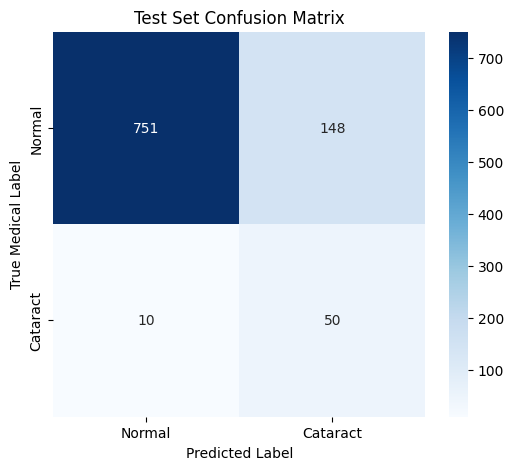

In [19]:
# ========================================
# Execute Phase 5
# ========================================
# I trigger evaluation logic using the newly trained architecture.
evaluate_model(trained_model, test_loader, device)